In [2]:
#Load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("C:/Users/tarun/Downloads/cluter/study_logs (1).csv")
df.head()


,Log_id,Student_id,Date,Day_name,Study_hour,Subject,Method_used,Distraction_time,Quiz_score
0,1,250001,2025-11-13,Thursday,2.37,English,Notes Review,29.6,80
1,2,250001,2025-11-14,Friday,1.89,Math,Videos,16.2,83
2,3,250001,2025-11-17,Monday,1.81,Science,Notes Review,34.4,71
3,4,250001,2025-11-18,Tuesday,1.80,Computer,Notes Review,34.8,60
4,5,250001,2025-11-19,Wednesday,2.11,English,Videos,23.6,76


In [3]:
# Average features per student
agg_df = df.groupby('Student_id').agg({
    'Study_hour':'mean',
    'Distraction_time':'mean',
    'Quiz_score':'mean'
}).reset_index()

# Add derived features
agg_df['Efficiency'] = agg_df['Study_hour'] / agg_df['Distraction_time']
agg_df['Quiz_per_hour'] = agg_df['Quiz_score'] / agg_df['Study_hour']

print(agg_df.head())


   Student_id  Study_hour  Distraction_time  Quiz_score  Efficiency  \
0      250001       1.949             25.99        74.8    0.074990   
1      250002       2.035             28.39        68.3    0.071680   
2      250003       1.449             45.91        39.8    0.031562   
3      250004       1.362             48.38        34.6    0.028152   
4      250005       2.121             26.08        72.4    0.081327   

   Quiz_per_hour  
0      38.378656  
1      33.562654  
2      27.467219  
3      25.403818  
4      34.134842  


In [4]:
features = ['Study_hour','Distraction_time','Quiz_score','Efficiency','Quiz_per_hour']


In [5]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(agg_df[features])

In [6]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)


In [7]:
k_range = range(2,6)  # test K=2..5
best_score = -1
best_k = 0

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k
        best_labels = labels

# Assign best cluster
agg_df['Cluster'] = best_labels
print(f"Best K={best_k} with Silhouette Score={best_score:.4f}")

K=2, Silhouette Score=0.6311
K=3, Silhouette Score=0.7544
K=4, Silhouette Score=0.5983
K=5, Silhouette Score=0.5699
Best K=3 with Silhouette Score=0.7544


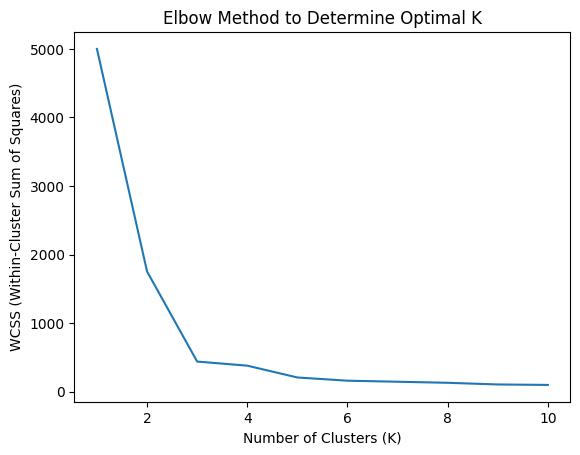

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

# Compute WCSS for K=1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow diagram
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method to Determine Optimal K")
plt.show()


In [9]:
# Summarize Clusters
features = ['Study_hour','Distraction_time','Quiz_score','Efficiency','Quiz_per_hour']

# Summarize clusters
cluster_summary = agg_df.groupby("Cluster")[features].mean().round(2)
print(cluster_summary)



         Study_hour  Distraction_time  Quiz_score  Efficiency  Quiz_per_hour
Cluster                                                                     
0              2.10             25.08       72.01        0.08          34.38
1              1.40             47.32       39.83        0.03          28.48
2              2.75             10.00       91.98        0.28          33.44


In [10]:
#PCA for visualizations
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Assign PCA components to agg_df
agg_df["PCA1"] = X_pca[:,0]
agg_df["PCA2"] = X_pca[:,1]

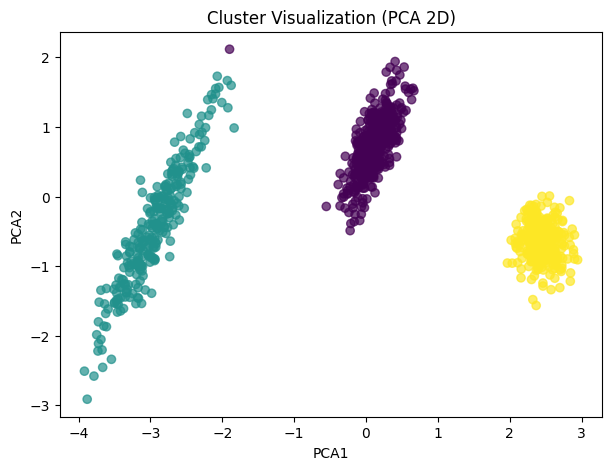

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(agg_df["PCA1"], agg_df["PCA2"], c=agg_df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Cluster Visualization (PCA 2D)")
plt.show()


Rule-Based Clustering Summary:


,Group,Count,Avg Study Hours,Avg Distraction,Avg Quiz Score,Avg Efficiency
0,High Performers,302,2.75,10.00,91.98,0.278
1,Average Performers,430,2.10,25.08,72.01,0.084
2,Low Performers,268,1.40,47.32,39.83,0.030
3,Efficient Students (Efficiency > 0.1),306,2.74,10.14,91.71,0.275
4,Focused Students (Distraction < 20),302,2.75,10.00,91.98,0.278
5,Top Scorers (Score > 80),302,2.75,10.00,91.98,0.278
6,Needs Intervention,269,1.40,47.32,39.86,0.030


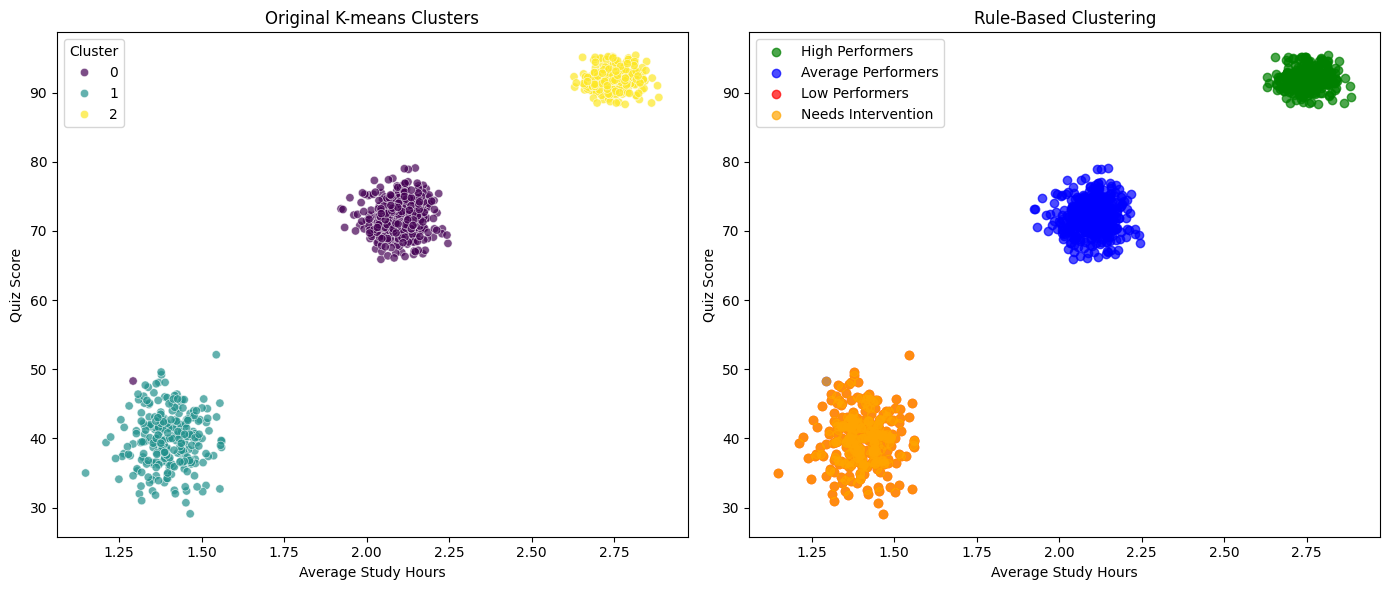

In [14]:
# Let's create a summary of the rule-based clusters we defined

# 1. Define our rule-based clusters
rule_based_clusters = {
    'High Performers': agg_df[agg_df['Cluster'] == 2],
    'Average Performers': agg_df[agg_df['Cluster'] == 0],
    'Low Performers': agg_df[agg_df['Cluster'] == 1],
    'Efficient Students (Efficiency > 0.1)': agg_df[agg_df['Efficiency'] > 0.1],
    'Focused Students (Distraction < 20)': agg_df[agg_df['Distraction_time'] < 20],
    'Top Scorers (Score > 80)': agg_df[agg_df['Quiz_score'] > 80],
    'Needs Intervention': agg_df[(agg_df['Distraction_time'] > 30) & (agg_df['Quiz_score'] < 60)]
}

# 2. Create a summary DataFrame
summary_data = []
for name, group in rule_based_clusters.items():
    if not group.empty:
        summary_data.append({
            'Group': name,
            'Count': len(group),
            'Avg Study Hours': group['Study_hour'].mean().round(2),
            'Avg Distraction': group['Distraction_time'].mean().round(2),
            'Avg Quiz Score': group['Quiz_score'].mean().round(2),
            'Avg Efficiency': group['Efficiency'].mean().round(3)
        })

# 3. Display the summary
summary_df = pd.DataFrame(summary_data)
print("Rule-Based Clustering Summary:")
display(summary_df)

# 4. Visualize the rule-based clusters
plt.figure(figsize=(14, 6))

# Plot 1: K-means clusters
plt.subplot(1, 2, 1)
sns.scatterplot(data=agg_df, x='Study_hour', y='Quiz_score', hue='Cluster', 
                palette='viridis', alpha=0.7)
plt.title('Original K-means Clusters')
plt.xlabel('Average Study Hours')
plt.ylabel('Quiz Score')

# Plot 2: Rule-based groups
plt.subplot(1, 2, 2)
colors = {'High Performers': 'green', 'Average Performers': 'blue', 
          'Low Performers': 'red', 'Needs Intervention': 'orange'}
for name, color in colors.items():
    if name in rule_based_clusters:
        group = rule_based_clusters[name]
        plt.scatter(group['Study_hour'], group['Quiz_score'], 
                   label=name, alpha=0.7, color=color)
plt.title('Rule-Based Clustering')
plt.xlabel('Average Study Hours')
plt.ylabel('Quiz Score')
plt.legend()

plt.tight_layout()
plt.show()